In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.analysis import pairplot

# --- CONNEXION À JULIA ---
from juliacall import Main as jl
jl.include("passerelle.jl")

# --- DÉFINITION DU SIMULATEUR POUR SBI ---
def simulateur_sbi_hybride(theta):
    theta = torch.atleast_2d(theta)
    resultats_simules = []
    
    # Les indices des 7 protocoles dans votre fichier Julia
    indices_protocoles = [1, 2, 3, 4, 5, 6, 7] 
    # Nombre de répétitions par protocole pour capter le bruit (variance)
    N_SWEEPS = 10 

    for jeu_de_parametres in theta:
        # 1. Extraction des 4 paramètres générés par le prior
        val_ampa = float(jeu_de_parametres[0])
        val_nmda = float(jeu_de_parametres[1])
        val_vgcc = float(jeu_de_parametres[2])
        val_neck = float(jeu_de_parametres[3])
        
        vecteur_cible = [] # Va contenir 14 valeurs (7 moyennes, 7 variances)
        
        # 2. Boucle sur les 7 protocoles de Tigaret
        for k_protocole in indices_protocoles:
            changements_de_poids = []
            
            # 3. Boucle des répétitions stochastiques
            for _ in range(N_SWEEPS):
                # /!\ IMPORTANT : Julia doit renvoyer UN SEUL CHIFFRE (Delta W), 
                # et prendre 5 arguments (les 4 params + l'indice du protocole)
                delta_w = jl.simuler_synapse_brute(val_ampa, val_nmda, val_vgcc, val_neck, k_protocole)
                changements_de_poids.append(float(delta_w))
            
            # 4. Calcul de la moyenne et de la variance
            moyenne_dw = np.mean(changements_de_poids)
            variance_dw = np.var(changements_de_poids)
            
            # On stocke dans le grand vecteur
            vecteur_cible.extend([moyenne_dw, variance_dw])
            
        # 5. Conversion en tenseur PyTorch pour SBI
        courbe_pytorch = torch.tensor(vecteur_cible, dtype=torch.float32)
        resultats_simules.append(courbe_pytorch)
        
    return torch.stack(resultats_simules)


# --- PROTOCOLE MACHINE LEARNING (SBI) ---

# Ordre : [N_ampa, N_nmda, N_vgcc, L_neck]
prior = BoxUniform(
    low=torch.tensor([10.0, 5.0, 0.0, 0.05]), 
    high=torch.tensor([300.0, 50.0, 20.0, 1.5]) 
)

print("\nLancement des simulations de l'IA...")
# J'ai mis 100 simulations pour tester. Montez ce chiffre quand vous lancerez la vraie optimisation de nuit.
theta_sim, x_sim = simulate_for_sbi(simulateur_sbi_hybride, prior, num_simulations=100, show_progress_bar=True)

print("Entraînement du réseau de neurones...")
inference = NPE(prior)
inference.append_simulations(theta_sim, x_sim)
inference.train()
posterior = inference.build_posterior()

print("Interface validée ! L'IA est entraînée.\n")

# --- ÉTAPE FINALE : INFÉRENCE AVEC LES VRAIES DONNÉES ---

print("Chargement des données expérimentales depuis Tigaret_data.jld2...")

# 1. On demande à Julia de charger le fichier JLD2
# Assurez-vous d'avoir bien importé JLD2 et FileIO dans votre environnement Julia
jl.seval('using JLD2, FileIO')
donnees_brutes = jl.load("Tigaret_data.jld2", "alldata")

# 2. Calcul dynamique de la moyenne et de la variance
cibles = []
for protocole in donnees_brutes:
    # On s'assure que les données sont bien un tableau numpy
    valeurs = np.array(protocole)
    
    moyenne = np.mean(valeurs)
    variance = np.var(valeurs) # Variance (ddof=0 par défaut dans numpy)
    
    cibles.extend([moyenne, variance])

# 3. Création du tenseur final pour SBI
x_observe = torch.tensor(cibles, dtype=torch.float32)

print("Tenseur cible x_observe calculé avec succès :")
print(x_observe)

# L'IA génère les paramètres qui correspondent le mieux à ces cibles
echantillons = posterior.sample((10000,), x=x_observe)

print("\nGénération terminée ! Vous pouvez maintenant analyser les résultats.")

# Facultatif : afficher le graphique des corrélations entre les paramètres
fig, axes = pairplot(echantillons, labels=["N_ampa", "N_nmda", "N_vgcc", "L_neck"])
plt.show()

/home/jean/derryInternship/SynapseElife.jl/sbi/env_sbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jean/derryInternship/SynapseElife.jl/sbi/env_sbi/lib/python3.13/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating new project at `~/derryInternship/SynapseElife.jl/sbi`
[ Info: Precompiling SciMLBasePythonCallExt [2797fd30-2078-5027-980c-4c2c8a19c528]
Precompiling packages...
Info Given SciMLBasePythonCallExt was explicitly requested, output will be shown live 
ERROR: LoadError: ArgumentError: Package PythonCall [6099a3de-0909-46bc-b1f4-468b9a2dfc0d] is required but does not seem to be installed:
 - Run `Pkg.instantiate()` to install all recorded dependencies.

Stacktrace:
  [1] __require_prelocked(pkg::Base.PkgId, env::String)
    @ Base ./loading.jl:2617
  [2] _require_prelocked(uuidkey::Base.PkgId, env::String)
    @ Base ./loading.jl:2495
  [3] macro expansion
    @ ./loading.jl:2423 [inlined]
  [4] macro expansion
    @ ./lock.jl:376 [inlined]
  [5] __require(into::Module, mod::Symbol)
    @ Base ./loading.jl:2388
  [6] require(into::Module, mod::Symbol)
    @ Base ./loading.jl:2364
  [7] top-level scope
    @ ~/.julia/packages/SciMLBase/O1HPI/ext/SciMLBasePythonCallExt.jl:3
  [8


Lancement des simulations de l'IA...


  0%|          | 0/100 [00:21<?, ?it/s]


JuliaError: KeyError: key :act_P not found
Stacktrace:
 [1] getindex(h::Dict{Symbol, AbstractArray}, key::Symbol)
   @ Base ./dict.jl:477
 [2] simuler_synapse_brute(val_n_ampa::Float64, val_n_nmda::Float64, val_n_vgcc::Float64, val_l_neck::Float64, k_protocole::Int64)
   @ Main ~/derryInternship/SynapseElife.jl/sbi/passerelle.jl:66
 [3] pyjlany_call(self::typeof(simuler_synapse_brute), args_::Py, kwargs_::Py)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/JksWe/src/JlWrap/any.jl:48
 [4] _pyjl_callmethod(f::Any, self_::Ptr{PythonCall.C.PyObject}, args_::Ptr{PythonCall.C.PyObject}, nargs::Int64)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/JksWe/src/JlWrap/base.jl:71
 [5] _pyjl_callmethod(o::Ptr{PythonCall.C.PyObject}, args::Ptr{PythonCall.C.PyObject})
   @ PythonCall.JlWrap.Cjl ~/.julia/packages/PythonCall/JksWe/src/JlWrap/C.jl:72

  0.158305 seconds (902.60 k allocations: 29.361 MiB)



--- TEST SCIENTIFIQUE (AVEC CALCIUM) ---
Génération de l'expérience secrète (AMPA=0.08, NMDA=0.02)...
L'IA tente de retrouver les valeurs secrètes à partir du Voltage ET du Calcium...


10052it [00:00, 69314.46it/s]                          


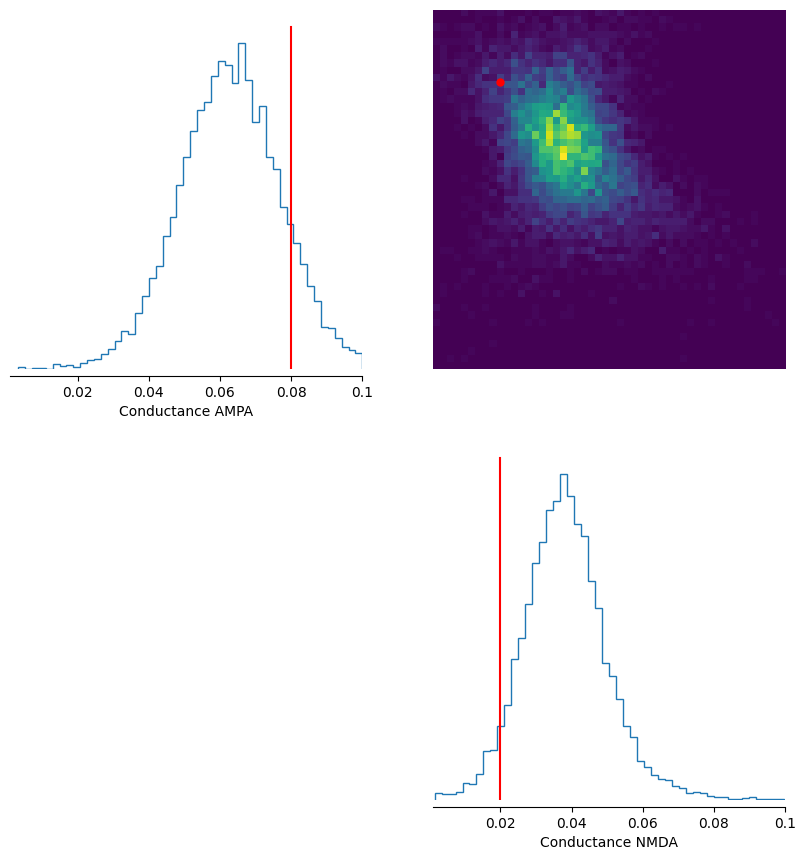

  0.139499 seconds (798.89 k allocations: 27.016 MiB)


In [52]:
print("\n--- TEST SCIENTIFIQUE (AVEC CALCIUM) ---")
vrai_ampa = 0.08
vrai_nmda = 0.02
print(f"Génération de l'expérience secrète (AMPA={vrai_ampa}, NMDA={vrai_nmda})...")

# On réceptionne les 3 variables pour la courbe secrète
t_cible, v_cible, ca_cible = jl.simuler_synapse_brute(vrai_ampa, vrai_nmda)

# On lisse et on combine exactement de la même manière
t_fixe = np.linspace(float(t_cible[0]), float(t_cible[-1]), 500)
v_fixe = np.interp(t_fixe, list(t_cible), list(v_cible))
ca_fixe = np.interp(t_fixe, list(t_cible), list(ca_cible))

courbe_cible_combinee = torch.tensor(np.concatenate([v_fixe, ca_fixe]), dtype=torch.float32)

print("L'IA tente de retrouver les valeurs secrètes à partir du Voltage ET du Calcium...")
echantillons_devines = posterior.sample((10000,), x=courbe_cible_combinee)

fig, axes = pairplot(
    echantillons_devines,
    limits=[[0.001, 0.1], [0.001, 0.1]], 
    labels=["Conductance AMPA", "Conductance NMDA"],
    points=[[vrai_ampa, vrai_nmda]], 
    points_colors=["red"]
)
plt.show()